# Constrained anchored Langevin, and its accuracy learning curve

Self-contained: **NumPy, pandas and matplotlib only** — no torch, and nothing from the
`ands` package. Run top to bottom and it fetches the data, samples the posterior, runs
its own exact reference, and draws the curve. About three minutes for both datasets.

## What is being sampled

For labels $y_i\in\{-1,+1\}$ and standardised features $\phi_i$, write $\psi_i=y_i\phi_i$.
The Gibbs posterior over classifier weights, restricted to a Euclidean ball, is

$$U(w)=\tau\,\frac1n\sum_i\max\bigl(0,\,1-w^{\!\top}\psi_i\bigr)+\lambda\lVert w\rVert_1,
\qquad \pi(w)\propto e^{-U(w)}\mathbf 1_K(w),\quad K=\{\lVert w\rVert_2\le R\}.$$

Both terms are non-differentiable — the hinge kinks at every active margin, the $\ell_1$
prior on every coordinate axis — and $U$ is only ever **evaluated**, never
differentiated. The sampler works from a smoothed anchor $U_0\ge U$ and the time change
$e^{\Delta}$, $\Delta=U-U_0$:

$$x\;\leftarrow\;P_K\Bigl(x-\eta\,e^{\Delta}\bigl[(I+J(x))\nabla U_0(x)-\nabla\!\cdot J(x)\bigr]
+\sqrt{2\eta}\,e^{\Delta/2}\,\xi\Bigr).$$

The hinge term is an **average, not a sum**. That one choice is what makes this work on
real data: with a sum the anchor gap grows like $n\tau\delta$ and $e^{\Delta}$ underflows,
so the sampler silently stops moving.

In [1]:
%matplotlib inline
import io
import urllib.request

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Everything the notebook depends on, in one place.
CFG = dict(
    tau=100.0,      # Gibbs inverse temperature on the mean hinge loss
    lam=1.0,        # L1 prior strength
    delta=0.02,     # anchor smoothing scale
    eta=3e-4,       # Langevin stepsize
    s=4.0,          # skew strength
    walkers=1000,
    steps=600,
    track_every=10,
    magic_rows=2000,
    ref_chains=800,
    ref_steps=4000,
    seed=106,
)
RADIUS = {"Titanic (survival)": 1.4, "MAGIC Gamma Telescope": 1.9}
CFG

{'tau': 100.0,
 'lam': 1.0,
 'delta': 0.02,
 'eta': 0.0003,
 's': 4.0,
 'walkers': 1000,
 'steps': 600,
 'track_every': 10,
 'magic_rows': 2000,
 'ref_chains': 800,
 'ref_steps': 4000,
 'seed': 106}

## The data

Titanic (891 passengers) and the MAGIC Gamma Telescope (a stratified 2 000-row subsample
of 19 020 events), both mirrored on GitHub. Features are standardised and an intercept is
prepended.

In [2]:
TITANIC_URL = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/titanic.csv"
MAGIC_URL = ("https://raw.githubusercontent.com/mikeizbicki/datasets/master/"
             "csv/uci/magic04.data")
MAGIC_COLS = ["fLength", "fWidth", "fSize", "fConc", "fConc1", "fAsym",
              "fM3Long", "fM3Trans", "fAlpha", "fDist", "class"]


def _fetch(url):
    with urllib.request.urlopen(url, timeout=120) as r:
        return io.BytesIO(r.read())


def standardise(X):
    """Zero mean, unit variance, constant columns dropped, intercept prepended."""
    X = np.asarray(X, float)
    X = X[:, X.std(axis=0) > 1e-12]
    X = (X - X.mean(axis=0)) / X.std(axis=0)
    return np.column_stack([np.ones(len(X)), X])


def load_titanic():
    df = pd.read_csv(_fetch(TITANIC_URL))
    df = df[["survived", "pclass", "sex", "age", "sibsp", "parch", "fare", "embarked"]].copy()
    df["age"] = df["age"].fillna(df["age"].median())
    df["fare"] = df["fare"].fillna(df["fare"].median())
    df["embarked"] = df["embarked"].fillna(df["embarked"].mode()[0])
    feats = np.column_stack([
        (df["pclass"] == 1), (df["pclass"] == 2), (df["sex"] == "female"),
        df["age"], df["sibsp"], df["parch"], np.log1p(df["fare"]),
        (df["embarked"] == "C"), (df["embarked"] == "Q")]).astype(float)
    return standardise(feats), np.where(df["survived"].values == 1, 1.0, -1.0)


def load_magic(n_max=2000, seed=0):
    df = pd.read_csv(_fetch(MAGIC_URL), header=None, names=MAGIC_COLS)
    y = np.where(df["class"].values == "g", 1.0, -1.0)
    X = df[MAGIC_COLS[:-1]].values.astype(float)
    for j, nm in enumerate(MAGIC_COLS[:-1]):          # heavy-tailed columns
        if nm in ("fLength", "fWidth", "fSize", "fDist"):
            X[:, j] = np.log(X[:, j] + 1e-6)
    if n_max is not None and n_max < len(df):         # stratified subsample
        rng = np.random.default_rng(seed)
        idx = np.concatenate([
            rng.choice(np.flatnonzero(y == c), int(round(n_max * np.mean(y == c))),
                       replace=False)
            for c in (1.0, -1.0)])
        rng.shuffle(idx)
        X, y = X[idx], y[idx]
    return standardise(X), y


DATA = {"Titanic (survival)": load_titanic(),
        "MAGIC Gamma Telescope": load_magic(CFG["magic_rows"])}
pd.DataFrame([{"dataset": k, "n": Phi.shape[0], "d": Phi.shape[1],
               "P(y=+1)": round(float((y > 0).mean()), 3), "R": RADIUS[k]}
              for k, (Phi, y) in DATA.items()]).set_index("dataset")

,n,d,P(y=+1),R
dataset,,,,
Titanic (survival),891,10,0.384,1.4
MAGIC Gamma Telescope,2000,11,0.648,1.9


## The target

$U$, its anchor $U_0$, the projection, and accuracy.

Both smoothings dominate what they replace ($\sqrt{z^2+\delta^2}\ge|z|$), so $U_0\ge U$
and $e^{\Delta}\in(0,1]$. `anchored_step` returns $\Delta$ and $\nabla U_0$ from a single
pass over the margins — forming that $(N,n)$ matrix is the whole cost of a step.

One detail in `accuracy_per_draw`: an exact zero margin counts as a coin flip. It matters
in exactly one place, and it is where the learning curve starts — at $w=0$ every margin
is exactly zero. For any $w\neq0$ on continuous features, ties have probability zero.

In [3]:
class BallGibbsSVM:
    def __init__(self, Phi, y, tau=100.0, lam=1.0, delta=0.02, R=1.4):
        self.Psi = y[:, None] * Phi                   # margin of w on row i is w.psi_i
        self.n, self.d = self.Psi.shape
        self.tau, self.lam, self.delta, self.R = tau, lam, delta, R

    def U(self, w):
        """The exact, non-differentiable potential. Evaluated, never differentiated."""
        z = 1.0 - w @ self.Psi.T
        return self.tau * np.maximum(z, 0.0).mean(1) + self.lam * np.abs(w).sum(1)

    def anchored_step(self, w):
        """(Delta, grad U0) from a single pass over the margins."""
        z = 1.0 - w @ self.Psi.T                      # (N, n)
        root = np.sqrt(z * z + self.delta ** 2)
        rw = np.sqrt(w * w + self.delta ** 2)
        Delta = (self.tau * (np.maximum(z, 0.0).mean(1) - (0.5 * (z + root)).mean(1))
                 + self.lam * (np.abs(w) - rw).sum(1))
        grad = (-(self.tau / self.n) * ((0.5 * (1.0 + z / root)) @ self.Psi)
                + self.lam * w / rw)
        return Delta, grad

    def project(self, w):
        nrm = np.linalg.norm(w, axis=1, keepdims=True)
        return w * np.minimum(1.0, self.R / np.maximum(nrm, 1e-300))

    def accuracy_per_draw(self, w):
        """Accuracy of each draw on its own; an exact zero margin counts as 1/2."""
        m = np.atleast_2d(w) @ self.Psi.T
        return ((m > 0) + 0.5 * (m == 0)).mean(axis=1)


TARGETS = {k: BallGibbsSVM(Phi, y, CFG["tau"], CFG["lam"], CFG["delta"], RADIUS[k])
           for k, (Phi, y) in DATA.items()}

# the anchor multiplier stays O(1) because the hinge is an average, not a sum
rng = np.random.default_rng(0)
for k, t in TARGETS.items():
    w = t.project(rng.normal(size=(2000, t.d)) * t.R / np.sqrt(t.d) * 2)
    Delta, _ = t.anchored_step(w)
    bound = t.tau * t.delta / 2 + t.lam * t.d * t.delta
    print("{:24s} min e^Delta = {:.4f}   (worst case allowed by the bound {:.4f})".format(
        k, np.exp(Delta).min(), np.exp(-bound)))

Titanic (survival)       min e^Delta = 0.8932   (worst case allowed by the bound 0.3012)


MAGIC Gamma Telescope    min e^Delta = 0.9158   (worst case allowed by the bound 0.2952)


## The three skew fields

Sampling on $K$ by projection puts **two** conditions on a skew field $J$. The flux must
be divergence-free — for a state-dependent $J$ that means carrying
$+\,e^{\Delta}\nabla\!\cdot J$ in the drift — and the skew drift must be tangential at the
wall, $J(x)\nu(x)=0$ on $\partial K$.

| | $J(x)$ | $\nabla\!\cdot J$ | $J\nu$ on $\partial K$ |
|---|---|---|---|
| `none` | $0$ | $0$ | $0$ |
| `const` | $sA$ | $0$ | $sA\nu \neq 0$ — **violates the wall condition** |
| `axial` | $\tfrac{s}{R^2}\bigl[\lVert x\rVert^2A+x(Ax)^{\!\top}-(Ax)x^{\!\top}\bigr]$ | $-\tfrac{s}{R^2}(d-2)Ax$ — **not zero for $d>2$** | $0$, identically |

The axial field annihilates $x$ for every $x$, so tangency at the wall holds by
construction. The $(d-2)$ is why a 3-dimensional study can get away with ignoring the
correction and a $d=10$ one cannot.

Both closed forms are checked below by central differences, with no knowledge of the
formulas.

In [4]:
def unit_skew(d):
    """Tridiagonal skew, scaled to unit spectral norm so that `s` means the same push
    for every field and every dimension."""
    A = np.diag(np.ones(d - 1), 1) - np.diag(np.ones(d - 1), -1)
    return A / np.linalg.norm(A, 2)


def skew_apply(kind, x, g, A, s, R):
    """J(x) g, row-wise."""
    if kind == "none":
        return np.zeros_like(g)
    if kind == "const":
        return s * (g @ A.T)
    c = s / R ** 2                                    # axial
    Ax, Ag = x @ A.T, g @ A.T
    r2 = (x * x).sum(1, keepdims=True)
    xg = (x * g).sum(1, keepdims=True)
    Axg = (Ax * g).sum(1, keepdims=True)
    return c * (r2 * Ag + Axg * x - xg * Ax)


def skew_div(kind, x, A, s, R, drop_correction=False):
    """div J in closed form."""
    if kind != "axial" or drop_correction:
        return np.zeros_like(x)
    return -(s / R ** 2) * (x.shape[1] - 2) * (x @ A.T)


def numeric_div(kind, x, A, s, R, h=1e-6):
    """(div J)_i = sum_j d_j J_ij by central differences -- an independent check."""
    d = x.shape[1]
    eye = np.eye(d)
    out = np.zeros_like(x)
    for j in range(d):
        step = h * eye[j]
        plus = skew_apply(kind, x + step, np.tile(eye[j], (len(x), 1)), A, s, R)
        minus = skew_apply(kind, x - step, np.tile(eye[j], (len(x), 1)), A, s, R)
        out += (plus - minus) / (2 * h)               # column j contributes to every i
    return out


rows = []
for name, t in TARGETS.items():
    A = unit_skew(t.d)
    xs = np.random.default_rng(11).normal(size=(6, t.d))
    wall = t.R * xs / np.linalg.norm(xs, axis=1, keepdims=True)
    nu = wall / np.linalg.norm(wall, axis=1, keepdims=True)
    for kind in ("const", "axial"):
        Jmat = np.stack([skew_apply(kind, np.tile(p, (t.d, 1)), np.eye(t.d), A,
                                    CFG["s"], t.R).T for p in xs])
        rows.append({
            "dataset": name, "field": kind, "d": t.d,
            "max |J + J^T|": "{:.1e}".format(np.abs(Jmat + np.transpose(Jmat, (0, 2, 1))).max()),
            "|div numeric - div closed|": "{:.1e}".format(np.abs(
                numeric_div(kind, xs, A, CFG["s"], t.R)
                - skew_div(kind, xs, A, CFG["s"], t.R)).max()),
            "mean ||div J|| on dK": round(float(np.linalg.norm(
                skew_div(kind, wall, A, CFG["s"], t.R), axis=1).mean()), 3),
            "mean ||J nu|| on dK": "{:.2e}".format(float(np.linalg.norm(
                skew_apply(kind, wall, nu, A, CFG["s"], t.R), axis=1).mean()))})
pd.DataFrame(rows).set_index(["dataset", "field"])

d max |J + J^T| |div numeric - div closed|  \
dataset               field                                                
Titanic (survival)    const  10       0.0e+00                    0.0e+00   
                      axial  10       1.8e-15                    1.8e-09   
MAGIC Gamma Telescope const  11       0.0e+00                    0.0e+00   
                      axial  11       4.4e-16                    1.2e-09   

                             mean ||div J|| on dK mean ||J nu|| on dK  
dataset               field                                            
Titanic (survival)    const                 0.000            2.77e+00  
                      axial                15.802            3.61e-16  
MAGIC Gamma Telescope const                 0.000            2.82e+00  
                      axial                13.378            4.75e-16

## The sampler

Projected anchored Langevin, started from $w=0$ — which is chance, so the accuracy trace
is a learning curve.

In [5]:
def run_chain(target, kind="none", s=0.0, eta=3e-4, n_steps=600, N=1000, seed=106,
              drop_correction=False, track_every=10):
    """Returns (iterations, accuracy trace, final sample).

    The trace has columns (mean, 5th percentile, 95th percentile) across walkers.
    """
    A = unit_skew(target.d)
    rng = np.random.default_rng(seed)
    x = np.zeros((N, target.d))
    sqrt2eta = np.sqrt(2.0 * eta)
    iters, acc = [], []

    def record(it):
        a = target.accuracy_per_draw(x)
        iters.append(it)
        acc.append([a.mean(), np.quantile(a, 0.05), np.quantile(a, 0.95)])

    record(0)                                         # the w = 0 start, at chance
    for it in range(n_steps):
        Delta, gU0 = target.anchored_step(x)
        drift = np.exp(Delta)[:, None] * (
            gU0 + skew_apply(kind, x, gU0, A, s, target.R)
            - skew_div(kind, x, A, s, target.R, drop_correction))
        noise = np.exp(0.5 * Delta)[:, None] * rng.standard_normal((N, target.d))
        x = target.project(x - eta * drift + sqrt2eta * noise)
        if (it + 1) % track_every == 0:
            record(it + 1)
    return np.array(iters), np.array(acc), x

## The ceiling

Where should the curve stop? At whatever the *exact* posterior scores — so the ceiling has
to be measured, not assumed. This is a Metropolis random walk against the exact non-smooth
$U$ with proposals outside $K$ rejected, which is reversible for $\pi\mathbf 1_K$ with no
projection bias.

It is **not** 1. These are linear classifiers on real, noisy data, and a sampler that
climbed past its own target's accuracy would be reporting a bug rather than a success.

In [6]:
def run_rwm(target, n_chains=800, n_steps=4000, step=None, seed=1):
    rng = np.random.default_rng(seed)
    scale = (2.38 / np.sqrt(target.d)) * 0.15 if step is None else step
    x = np.zeros((n_chains, target.d))
    Ux = target.U(x)
    accepted = 0
    for _ in range(n_steps):
        prop = x + scale * rng.standard_normal((n_chains, target.d))
        inside = np.linalg.norm(prop, axis=1) <= target.R
        Up = np.where(inside, target.U(prop), np.inf)
        take = (np.log(rng.random(n_chains)) < (Ux - Up)) & inside
        x = np.where(take[:, None], prop, x)
        Ux = np.where(take, Up, Ux)
        accepted += take.mean()
    return x, accepted / n_steps


CEILING = {}
for name, t in TARGETS.items():
    ref, acc_rate = run_rwm(t, CFG["ref_chains"], CFG["ref_steps"])
    CEILING[name] = float(t.accuracy_per_draw(ref).mean())
    print("{:24s} RWM acceptance {:.3f}   ceiling {:.4f}".format(
        name, acc_rate, CEILING[name]))

Titanic (survival)       RWM acceptance 0.176   ceiling 0.7895


MAGIC Gamma Telescope    RWM acceptance 0.293   ceiling 0.7828


## Run the four samplers

In [7]:
METHODS = [("none", 0.0, False, "J = 0"),
           ("const", CFG["s"], False, "constant $J_a$"),
           ("axial", CFG["s"], False, "state-dependent $J_s$"),
           ("axial", CFG["s"], True, "$J_s$, correction dropped")]

CURVES, summary = {}, []
for name, t in TARGETS.items():
    CURVES[name] = {}
    for kind, s, drop, label in METHODS:
        it, acc, _ = run_chain(t, kind, s, eta=CFG["eta"], n_steps=CFG["steps"],
                               N=CFG["walkers"], seed=CFG["seed"],
                               drop_correction=drop, track_every=CFG["track_every"])
        CURVES[name][label] = (it, acc)
        reached = acc[:, 0] >= 0.99 * CEILING[name]
        summary.append({"dataset": name, "method": label.replace("$", ""),
                        "start": round(float(acc[0, 0]), 3),
                        "iters to 99% of ceiling": int(it[np.argmax(reached)]) if reached.any() else None,
                        "final": round(float(acc[-1, 0]), 4),
                        "ceiling": round(CEILING[name], 4)})
pd.DataFrame(summary).set_index(["dataset", "method"])

start  iters to 99% of ceiling  \
dataset               method                                                    
Titanic (survival)    J = 0                      0.5                      120   
                      constant J_a               0.5                      140   
                      state-dependent J_s        0.5                       90   
                      J_s, correction dropped    0.5                      100   
MAGIC Gamma Telescope J = 0                      0.5                      190   
                      constant J_a               0.5                      100   
                      state-dependent J_s        0.5                      170   
                      J_s, correction dropped    0.5                      150   

                                                final  ceiling  
dataset               method                                    
Titanic (survival)    J = 0                    0.7894   0.7895  
                      constant J_a             0.7894   0.7895  
                      state-dependent J_s      0.7891   0.7895  
                      J_s, correction dropped  0.7888   0.7895  
MAGIC Gamma Telescope J = 0                    0.7822   0.7828  
                      constant J_a             0.7849   0.7828  
                      state-dependent J_s      0.7830   0.7828  
                      J_s, correction dropped  0.7853   0.7828

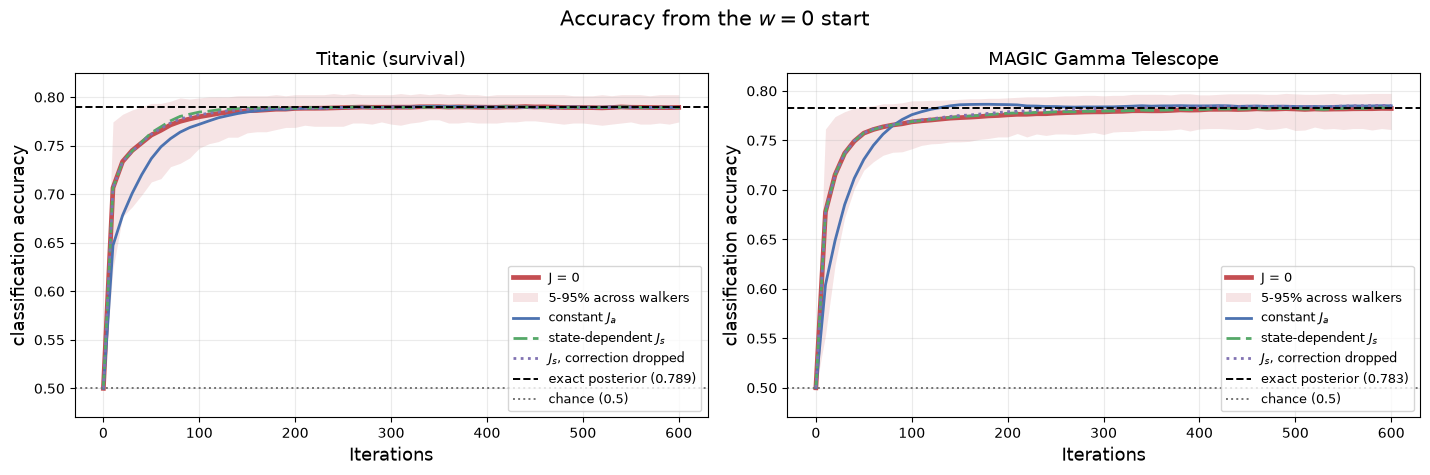

In [8]:
COLORS = {"J = 0": "#C44E52", "constant $J_a$": "#4C72B0",
          "state-dependent $J_s$": "#55A868", "$J_s$, correction dropped": "#8172B2"}
STYLES = ["-", "-", (0, (5, 2)), (0, (1, 1.6))]       # the admissible runs overlap
WIDTHS = [3.4, 2.0, 2.0, 2.0]

fig, axes = plt.subplots(1, len(CURVES), figsize=(7.2 * len(CURVES), 4.8), squeeze=False)
for ax, (name, curves) in zip(axes[0], CURVES.items()):
    for (label, (it, acc)), ls, lw in zip(curves.items(), STYLES, WIDTHS):
        ax.plot(it, acc[:, 0], color=COLORS[label], linewidth=lw, linestyle=ls, label=label)
        if label == "J = 0":
            ax.fill_between(it, acc[:, 1], acc[:, 2], color=COLORS[label], alpha=0.15,
                            linewidth=0, label="5-95% across walkers")
    ax.axhline(CEILING[name], color="k", linestyle="--", linewidth=1.4,
               label="exact posterior ({:.3f})".format(CEILING[name]))
    ax.axhline(0.5, color="0.45", linestyle=":", linewidth=1.4, label="chance (0.5)")
    ax.set_xlabel("Iterations", fontsize=13)
    ax.set_ylabel("classification accuracy", fontsize=13)
    ax.set_title(name, fontsize=13)
    ax.set_ylim(0.47, CEILING[name] + 0.035)
    ax.grid(True, alpha=0.25)
    ax.legend(fontsize=9, loc="lower right")
fig.suptitle("Accuracy from the $w = 0$ start", fontsize=15)
fig.tight_layout()
plt.show()

## What to read off it

Every chain leaves $w=0$ at exactly 0.5 and reaches the posterior's own rate — about
0.79 on both datasets — inside roughly 100–200 iterations.

During the climb the **constant field is the slowest of the three**, which is the only
part of this figure that ranks the methods honestly. It is antisymmetric and
divergence-free, and fails only the wall condition $J\nu=0$; that single defect is enough
to cost it early progress.

Read the "iterations to 99% of ceiling" column with care. On MAGIC the constant field
appears to arrive *first*, but only because it overshoots to a plateau above the true
ceiling and crosses the threshold on its way past — converging to the wrong place, not
converging faster. The overshoot is visible in the curve.

That is the general warning this notebook exists to make: accuracy is close to blind to
sampling bias. $\operatorname{sign}(w^{\!\top}\psi_i)$ is invariant under $w\mapsto cw$, so
a scale-invariant statistic cannot see the dominant distortion an inadmissible field
produces, which is radial — mass driven out towards the wall. **A constrained sampler
validated on downstream accuracy is not validated at all**; that needs $W_1$ against a
trusted reference, which is what the main study in this repository does.